# 05 — Late Fusion: HuBERT Audio + DistilBERT Text

Weighted late fusion of HuBERT audio predictions and DistilBERT text predictions on IEMOCAP (5-class: angry, happy, neutral, sad, frustrated).

**What this notebook does (no retraining involved):**
1. Loads pre-computed HuBERT audio probability CSVs
2. Loads pre-computed DistilBERT text probability CSVs (raises `FileNotFoundError` if missing — no TF-IDF fallback)
3. Aligns rows using `orig_idx` and verifies identical true labels
4. Searches 21 audio/text weight combinations (0.00 → 1.00, step 0.05) on the **validation set only**
5. Evaluates the best weight on the **test set** and saves all artefacts

**Prerequisites:** The following files must exist:
- `outputs/hubert_audio_baseline/hubert_val_predictions_with_probs.csv`
- `outputs/hubert_audio_baseline/hubert_test_predictions_with_probs.csv`
- `outputs/hubert_audio_baseline/hubert_final_metrics.json`
- `outputs/hubert_audio_baseline/bert_text_val_predictions_with_probs.csv`  
  *(or fallback: `bert_text_best_val_predictions_with_probs.csv`)*
- `outputs/hubert_audio_baseline/bert_text_test_predictions_with_probs.csv`  
  *(or fallback: `bert_text_best_test_predictions_with_probs.csv`)*
- `outputs/hubert_audio_baseline/bert_text_final_metrics.json`

---
## 1. Configuration

In [3]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Directory layout
NOTEBOOK_DIR   = Path('.')
OUTPUTS_DIR    = NOTEBOOK_DIR / 'outputs'
HUBERT_DIR     = OUTPUTS_DIR / 'hubert_audio_baseline'
FUSION_OUT_DIR = OUTPUTS_DIR / 'fusion_bert_hubert'
FUSION_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Emotion classes — must match HuBERT label order
EMOTIONS   = ['angry', 'happy', 'neutral', 'sad', 'frustrated']
EMOTION2ID = {e: i for i, e in enumerate(EMOTIONS)}
PROB_COLS  = [f'prob_{e}' for e in EMOTIONS]

# Fusion weight grid: audio weight from 0.0 to 1.0 inclusive, step 0.05 (21 points)
WEIGHT_GRID = np.round(np.arange(0.0, 1.01, 0.05), 2).tolist()

print(f'Output directory : {FUSION_OUT_DIR.resolve()}')
print(f'Emotion classes  : {EMOTIONS}')
print(f'Weight grid ({len(WEIGHT_GRID)} points): {WEIGHT_GRID}')

Output directory : C:\Users\PC\Desktop\תואר\שנה ג\Project\IEMOCAP-project\notebooks\outputs\fusion_bert_hubert
Emotion classes  : ['angry', 'happy', 'neutral', 'sad', 'frustrated']
Weight grid (21 points): [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]


---
## 2. Load DistilBERT Text Predictions

Loads pre-computed DistilBERT probability CSVs from `outputs/hubert_audio_baseline/`.

**Naming-convention fallback (in priority order):**

| Priority | Val CSV | Test CSV |
|----------|---------|----------|
| Preferred | `bert_text_val_predictions_with_probs.csv` | `bert_text_test_predictions_with_probs.csv` |
| Fallback | `bert_text_best_val_predictions_with_probs.csv` | `bert_text_best_test_predictions_with_probs.csv` |

The metrics file is always `bert_text_final_metrics.json` (no fallback).  
If neither CSV variant exists, a `FileNotFoundError` is raised. Do NOT use TF-IDF as a fallback.

In [ ]:
# Preferred filenames for DistilBERT prediction CSVs
BERT_VAL_PATH_PREF  = HUBERT_DIR / 'bert_text_val_predictions_with_probs.csv'
BERT_TEST_PATH_PREF = HUBERT_DIR / 'bert_text_test_predictions_with_probs.csv'

# Fallback filenames (used only when the preferred CSVs do not exist)
BERT_VAL_PATH_FALL  = HUBERT_DIR / 'bert_text_best_val_predictions_with_probs.csv'
BERT_TEST_PATH_FALL = HUBERT_DIR / 'bert_text_best_test_predictions_with_probs.csv'

# Metrics JSON — fixed name, no fallback
BERT_METRICS_PATH = HUBERT_DIR / 'bert_text_final_metrics.json'

# Resolve val CSV
if BERT_VAL_PATH_PREF.exists():
    BERT_VAL_PATH = BERT_VAL_PATH_PREF
elif BERT_VAL_PATH_FALL.exists():
    BERT_VAL_PATH = BERT_VAL_PATH_FALL
    print(f'Note: preferred val CSV not found; using fallback → {BERT_VAL_PATH.name}')
else:
    raise FileNotFoundError(
        'DistilBERT val predictions not found. Checked:\n'
        f'  {BERT_VAL_PATH_PREF}\n'
        f'  {BERT_VAL_PATH_FALL}\n'
        'Run the DistilBERT text baseline notebook first. '
        'Do NOT use TF-IDF as a fallback.'
    )

# Resolve test CSV
if BERT_TEST_PATH_PREF.exists():
    BERT_TEST_PATH = BERT_TEST_PATH_PREF
elif BERT_TEST_PATH_FALL.exists():
    BERT_TEST_PATH = BERT_TEST_PATH_FALL
    print(f'Note: preferred test CSV not found; using fallback → {BERT_TEST_PATH.name}')
else:
    raise FileNotFoundError(
        'DistilBERT test predictions not found. Checked:\n'
        f'  {BERT_TEST_PATH_PREF}\n'
        f'  {BERT_TEST_PATH_FALL}\n'
        'Run the DistilBERT text baseline notebook first. '
        'Do NOT use TF-IDF as a fallback.'
    )

# Metrics file (required, no fallback)
if not BERT_METRICS_PATH.exists():
    raise FileNotFoundError(
        f'DistilBERT metrics file not found: {BERT_METRICS_PATH}\n'
        'Run the DistilBERT text baseline notebook first. '
        'Do NOT use TF-IDF as a fallback.'
    )

bert_val_raw  = pd.read_csv(BERT_VAL_PATH)
bert_test_raw = pd.read_csv(BERT_TEST_PATH)

# Standardise column names
for df in (bert_val_raw, bert_test_raw):
    df.rename(columns={'true_emotion': 'true_label', 'pred_emotion': 'pred_label'}, inplace=True)

with open(BERT_METRICS_PATH) as f:
    bert_metrics = json.load(f)

print('DistilBERT predictions loaded:')
print(f'  val  : {BERT_VAL_PATH.name}  ({len(bert_val_raw):,} rows)')
print(f'  test : {BERT_TEST_PATH.name}  ({len(bert_test_raw):,} rows)')
print()
print(f'DistilBERT val  — Acc: {bert_metrics["val_accuracy"]:.4f}  UAR: {bert_metrics["val_uar"]:.4f}  Macro F1: {bert_metrics["val_macro_f1"]:.4f}')
print(f'DistilBERT test — Acc: {bert_metrics["test_accuracy"]:.4f}  UAR: {bert_metrics["test_uar"]:.4f}  Macro F1: {bert_metrics["test_macro_f1"]:.4f}')

---
## 3. Load HuBERT Audio Predictions

In [5]:
HUBERT_VAL_PATH     = HUBERT_DIR / 'hubert_val_predictions_with_probs.csv'
HUBERT_TEST_PATH    = HUBERT_DIR / 'hubert_test_predictions_with_probs.csv'
HUBERT_METRICS_PATH = HUBERT_DIR / 'hubert_final_metrics.json'

for fpath in (HUBERT_VAL_PATH, HUBERT_TEST_PATH, HUBERT_METRICS_PATH):
    if not fpath.exists():
        raise FileNotFoundError(f'HuBERT file not found: {fpath}')

hubert_val_raw  = pd.read_csv(HUBERT_VAL_PATH)
hubert_test_raw = pd.read_csv(HUBERT_TEST_PATH)

# Standardise column names: HuBERT uses true_emotion / pred_emotion
for df in (hubert_val_raw, hubert_test_raw):
    df.rename(columns={'true_emotion': 'true_label', 'pred_emotion': 'pred_label'}, inplace=True)

print('Raw prediction counts:')
print(f'  HuBERT val      : {len(hubert_val_raw):>5,} samples')
print(f'  HuBERT test     : {len(hubert_test_raw):>5,} samples')
print(f'  DistilBERT val  : {len(bert_val_raw):>5,} samples')
print(f'  DistilBERT test : {len(bert_test_raw):>5,} samples')

if len(hubert_val_raw) != len(bert_val_raw):
    print()
    print('Note: sample counts differ — aligning on the intersection of orig_idx values.')

Raw prediction counts:
  HuBERT val      : 2,052 samples
  HuBERT test     : 2,118 samples
  DistilBERT val  : 2,052 samples
  DistilBERT test : 2,118 samples


In [6]:
def align_on_orig_idx(audio_df, text_df, split_name):
    """Inner join on orig_idx; sort both by orig_idx for identical ordering."""
    audio_sorted = audio_df.sort_values('orig_idx').reset_index(drop=True)
    text_sorted  = text_df.sort_values('orig_idx').reset_index(drop=True)

    common_idx = set(audio_sorted['orig_idx']) & set(text_sorted['orig_idx'])

    audio_aligned = audio_sorted[audio_sorted['orig_idx'].isin(common_idx)].reset_index(drop=True)
    text_aligned  = text_sorted[ text_sorted['orig_idx'].isin(common_idx)].reset_index(drop=True)

    dropped_audio = len(audio_sorted) - len(audio_aligned)
    dropped_text  = len(text_sorted)  - len(text_aligned)
    if dropped_audio:
        print(f'[{split_name}] Dropped {dropped_audio} HuBERT rows not found in DistilBERT set')
    if dropped_text:
        print(f'[{split_name}] Dropped {dropped_text} DistilBERT rows not found in HuBERT set')

    return audio_aligned, text_aligned


audio_val,  bert_val  = align_on_orig_idx(hubert_val_raw,  bert_val_raw,  'val')
audio_test, bert_test = align_on_orig_idx(hubert_test_raw, bert_test_raw, 'test')

print(f'Aligned val  : {len(audio_val):,} samples')
print(f'Aligned test : {len(audio_test):,} samples')

Aligned val  : 2,052 samples
Aligned test : 2,118 samples


---
## 4. Sanity Checks

Before any fusion, verify that the aligned prediction DataFrames are fully compatible.

In [7]:
def run_sanity_checks(audio_df, text_df, split_name, prob_tol=1e-4):
    """Raise ValueError if any alignment or integrity check fails."""
    errors = []

    # 1. Equal sample counts
    if len(audio_df) != len(text_df):
        errors.append(f'Sample count mismatch — audio: {len(audio_df)}, text: {len(text_df)}')

    # 2. Identical orig_idx values
    if not np.array_equal(audio_df['orig_idx'].values, text_df['orig_idx'].values):
        errors.append('orig_idx values differ between audio and text DataFrames')

    # 3. Identical ordering (element-wise)
    if audio_df['orig_idx'].tolist() != text_df['orig_idx'].tolist():
        errors.append('orig_idx ordering differs between audio and text DataFrames')

    # 4. Identical true labels
    if not np.array_equal(audio_df['true_label'].values, text_df['true_label'].values):
        n_diff = (audio_df['true_label'].values != text_df['true_label'].values).sum()
        errors.append(f'true_label differs in {n_diff} rows')

    # 5. Probability rows sum to 1
    for tag, df in [('audio', audio_df), ('text', text_df)]:
        prob_sums = df[PROB_COLS].sum(axis=1)
        max_dev   = (prob_sums - 1.0).abs().max()
        if max_dev > prob_tol:
            errors.append(f'{tag} probabilities do not sum to 1 (max deviation = {max_dev:.6f})')

    if errors:
        for msg in errors:
            print(f'  [FAIL] {msg}')
        raise ValueError(f'Sanity checks FAILED for {split_name} ({len(errors)} error(s)). '
                         'Fix the issues above before running fusion.')

    print(f'[{split_name}] All 5 sanity checks PASSED  ({len(audio_df):,} aligned samples)')


run_sanity_checks(audio_val,  bert_val,  'val')
run_sanity_checks(audio_test, bert_test, 'test')

[val] All 5 sanity checks PASSED  (2,052 aligned samples)
[test] All 5 sanity checks PASSED  (2,118 aligned samples)


---
## 5. Validation Fusion Search

Sweep over 21 audio/text weight combinations (audio weight 0.00 → 1.00, step 0.05).  
Model selection is based **exclusively on validation UAR** — test results are not consulted.

In [8]:
def weighted_fusion(audio_df, text_df, audio_weight):
    """Weighted average of probability vectors; predict via argmax."""
    text_weight  = 1.0 - audio_weight
    audio_probs  = audio_df[PROB_COLS].values
    text_probs   = text_df[PROB_COLS].values

    fusion_probs = audio_weight * audio_probs + text_weight * text_probs
    pred_labels  = [EMOTIONS[i] for i in np.argmax(fusion_probs, axis=1)]
    true_labels  = audio_df['true_label'].tolist()

    acc = accuracy_score(true_labels, pred_labels)
    f1  = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    uar = balanced_accuracy_score(true_labels, pred_labels)

    return pred_labels, fusion_probs, acc, f1, uar

In [9]:
val_records = []
for audio_w in WEIGHT_GRID:
    _, _, acc, f1, uar = weighted_fusion(audio_val, bert_val, audio_w)
    val_records.append({
        'audio_weight': audio_w,
        'text_weight':  round(1.0 - audio_w, 2),
        'val_accuracy': round(acc, 4),
        'val_macro_f1': round(f1,  4),
        'val_uar':      round(uar, 4),
    })

val_results_df = pd.DataFrame(val_records)

print('Validation Fusion Search Results:')
print(val_results_df.to_string(index=False))

Validation Fusion Search Results:
 audio_weight  text_weight  val_accuracy  val_macro_f1  val_uar
         0.00         1.00        0.4966        0.4784   0.5369
         0.05         0.95        0.5049        0.4873   0.5455
         0.10         0.90        0.5132        0.4956   0.5538
         0.15         0.85        0.5234        0.5049   0.5618
         0.20         0.80        0.5234        0.5044   0.5623
         0.25         0.75        0.5351        0.5159   0.5730
         0.30         0.70        0.5404        0.5211   0.5768
         0.35         0.65        0.5541        0.5360   0.5919
         0.40         0.60        0.5599        0.5445   0.5960
         0.45         0.55        0.5595        0.5490   0.5966
         0.50         0.50        0.5487        0.5453   0.5871
         0.55         0.45        0.5468        0.5465   0.5804
         0.60         0.40        0.5419        0.5431   0.5667
         0.65         0.35        0.5322        0.5313   0.5498
      

---
## 6. Best Weight Selection

Select the weight with the highest **validation UAR**.  
Test results are not consulted at this stage.

In [10]:
best_row     = val_results_df.loc[val_results_df['val_uar'].idxmax()]
BEST_AUDIO_W = float(best_row['audio_weight'])
BEST_TEXT_W  = float(best_row['text_weight'])
BEST_VAL_UAR = float(best_row['val_uar'])
BEST_VAL_F1  = float(best_row['val_macro_f1'])
BEST_VAL_ACC = float(best_row['val_accuracy'])

print(f'Best audio weight   : {BEST_AUDIO_W}')
print(f'Best text  weight   : {BEST_TEXT_W}')
print(f'Validation UAR      : {BEST_VAL_UAR:.4f}')
print(f'Validation Macro F1 : {BEST_VAL_F1:.4f}')
print(f'Validation Accuracy : {BEST_VAL_ACC:.4f}')

Best audio weight   : 0.45
Best text  weight   : 0.55
Validation UAR      : 0.5966
Validation Macro F1 : 0.5490
Validation Accuracy : 0.5595


---
## 7. Test Evaluation

Evaluate the best-weight fusion model on the held-out **test set**.

In [11]:
test_pred_labels, test_fusion_probs, test_acc, test_f1, test_uar = \
    weighted_fusion(audio_test, bert_test, BEST_AUDIO_W)

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test UAR      : {test_uar:.4f}')
print(f'Test Macro F1 : {test_f1:.4f}')
print()
print('Classification Report:')
print(classification_report(
    audio_test['true_label'],
    test_pred_labels,
    target_names=EMOTIONS,
    zero_division=0,
))

Test Accuracy : 0.5670
Test UAR      : 0.5895
Test Macro F1 : 0.5606

Classification Report:
              precision    recall  f1-score   support

       angry       0.42      0.69      0.52       197
       happy       0.53      0.38      0.45       611
     neutral       0.79      0.67      0.72       613
         sad       0.46      0.62      0.53       386
  frustrated       0.58      0.59      0.58       311

    accuracy                           0.57      2118
   macro avg       0.56      0.59      0.56      2118
weighted avg       0.59      0.57      0.57      2118



In [12]:
cm = confusion_matrix(
    audio_test['true_label'],
    test_pred_labels,
    labels=EMOTIONS,
)

cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)
cm_df.index.name   = 'true'
cm_df.columns.name = 'pred'
print('Confusion Matrix (rows = true, cols = predicted):')
print(cm_df)

Confusion Matrix (rows = true, cols = predicted):
pred        angry  happy  neutral  sad  frustrated
true                                              
angry         136      4       15    3          39
happy          11    408      109   35          50
neutral         6     40      240   31          69
sad            16     31       30  182          52
frustrated    153     33      125   65         235


---
## 8. Visualizations

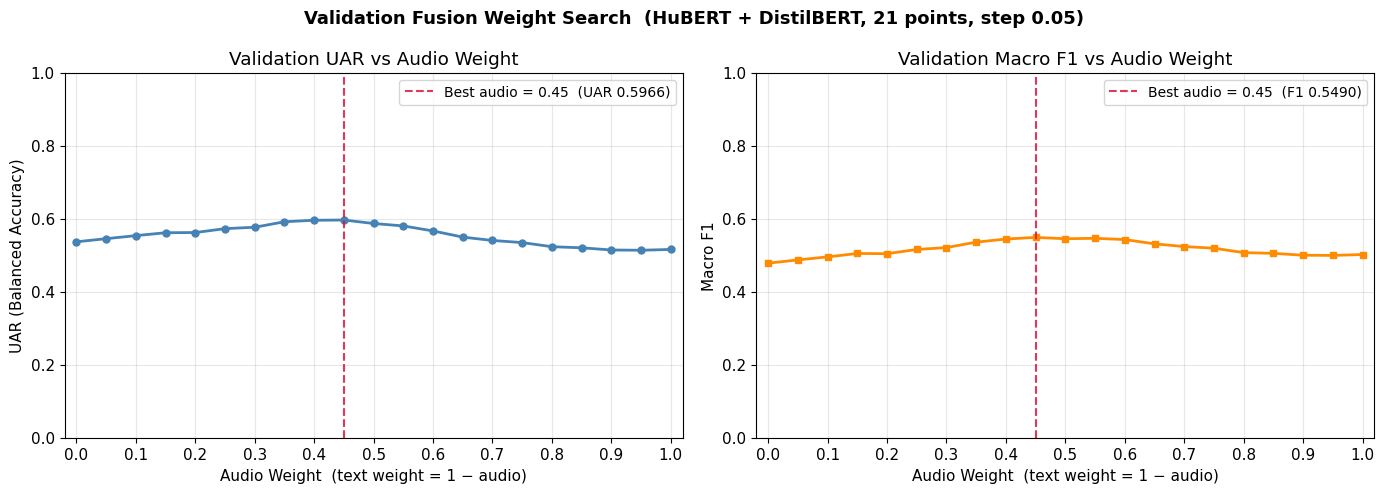

Saved: fusion_weight_search.png


In [13]:
matplotlib.rcParams.update({'font.size': 11})

x           = val_results_df['audio_weight'].values
major_ticks = np.round(np.arange(0.0, 1.01, 0.1), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validation Fusion Weight Search  (HuBERT + DistilBERT, 21 points, step 0.05)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(x, val_results_df['val_uar'], 'o-', color='steelblue', linewidth=2, markersize=5)
ax.axvline(BEST_AUDIO_W, color='crimson', linestyle='--', linewidth=1.5, alpha=0.85,
           label=f'Best audio = {BEST_AUDIO_W}  (UAR {BEST_VAL_UAR:.4f})')
ax.set_title('Validation UAR vs Audio Weight')
ax.set_xlabel('Audio Weight  (text weight = 1 − audio)')
ax.set_ylabel('UAR (Balanced Accuracy)')
ax.set_xticks(major_ticks)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(axis='both', alpha=0.3)

ax = axes[1]
ax.plot(x, val_results_df['val_macro_f1'], 's-', color='darkorange', linewidth=2, markersize=5)
ax.axvline(BEST_AUDIO_W, color='crimson', linestyle='--', linewidth=1.5, alpha=0.85,
           label=f'Best audio = {BEST_AUDIO_W}  (F1 {BEST_VAL_F1:.4f})')
ax.set_title('Validation Macro F1 vs Audio Weight')
ax.set_xlabel('Audio Weight  (text weight = 1 − audio)')
ax.set_ylabel('Macro F1')
ax.set_xticks(major_ticks)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.savefig(FUSION_OUT_DIR / 'fusion_weight_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fusion_weight_search.png')

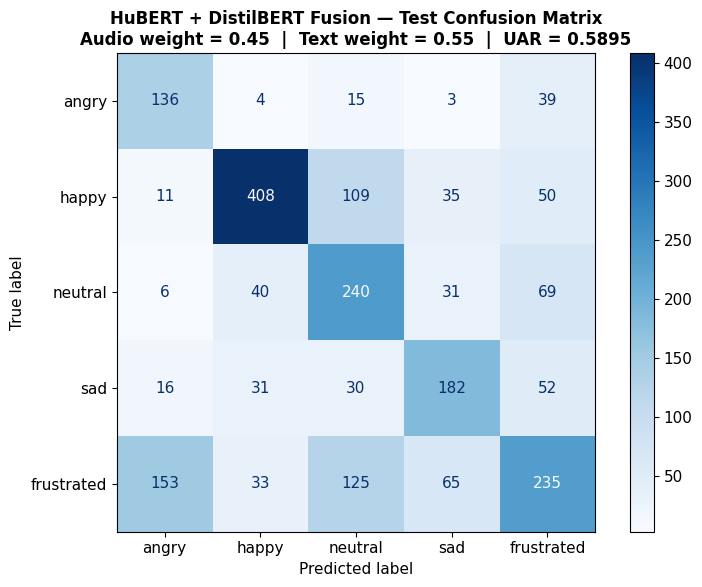

Saved: fusion_confusion_matrix.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTIONS)
disp.plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title(
    f'HuBERT + DistilBERT Fusion — Test Confusion Matrix\n'
    f'Audio weight = {BEST_AUDIO_W}  |  Text weight = {BEST_TEXT_W}  |  '
    f'UAR = {test_uar:.4f}',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig(FUSION_OUT_DIR / 'fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fusion_confusion_matrix.png')

---
## 9. Final Comparison

Compare HuBERT Audio, DistilBERT Text, and HuBERT + DistilBERT Fusion on the same test samples.

In [15]:
# HuBERT test metrics — read from the saved JSON
with open(HUBERT_METRICS_PATH) as f:
    hubert_metrics = json.load(f)

hubert_test_acc = hubert_metrics['final_test_accuracy']
hubert_test_uar = hubert_metrics['final_test_uar']
hubert_test_f1  = hubert_metrics['final_test_macro_f1']

# DistilBERT metrics on the aligned test samples (same set as HuBERT / fusion)
true_labels_test   = audio_test['true_label'].tolist()
bert_preds_aligned = bert_test['pred_label'].tolist()

bert_test_acc = accuracy_score(true_labels_test, bert_preds_aligned)
bert_test_uar = balanced_accuracy_score(true_labels_test, bert_preds_aligned)
bert_test_f1  = f1_score(true_labels_test, bert_preds_aligned, average='macro', zero_division=0)

comparison_df = pd.DataFrame([
    {'Model': 'HuBERT Audio',              'Accuracy': hubert_test_acc, 'UAR': hubert_test_uar, 'Macro F1': hubert_test_f1},
    {'Model': 'DistilBERT Text',           'Accuracy': bert_test_acc,   'UAR': bert_test_uar,   'Macro F1': bert_test_f1},
    {'Model': 'HuBERT + DistilBERT Fusion','Accuracy': test_acc,        'UAR': test_uar,        'Macro F1': test_f1},
]).set_index('Model').round(4)

print('Final Model Comparison — Test Set:')
print(comparison_df.to_string())

Final Model Comparison — Test Set:
                            Accuracy     UAR  Macro F1
Model                                                 
HuBERT Audio                  0.4778  0.4952    0.4752
DistilBERT Text               0.5137  0.5408    0.4993
HuBERT + DistilBERT Fusion    0.5670  0.5895    0.5606


---
## 10. Fusion Improvement Analysis

In [16]:
fusion_vs_hubert_uar      = test_uar - hubert_test_uar
fusion_vs_bert_uar        = test_uar - bert_test_uar
fusion_vs_hubert_macro_f1 = test_f1  - hubert_test_f1
fusion_vs_bert_macro_f1   = test_f1  - bert_test_f1

print('Fusion improvement over HuBERT Audio:')
print(f'  UAR      : {fusion_vs_hubert_uar:+.4f}')
print(f'  Macro F1 : {fusion_vs_hubert_macro_f1:+.4f}')
print()
print('Fusion improvement over DistilBERT Text:')
print(f'  UAR      : {fusion_vs_bert_uar:+.4f}')
print(f'  Macro F1 : {fusion_vs_bert_macro_f1:+.4f}')

Fusion improvement over HuBERT Audio:
  UAR      : +0.0943
  Macro F1 : +0.0854

Fusion improvement over DistilBERT Text:
  UAR      : +0.0487
  Macro F1 : +0.0613


---
## 11. Final Summary

In [17]:
hubert_preds_aligned = audio_test['pred_label'].tolist()
n_changed_vs_hubert  = sum(f != h for f, h in zip(test_pred_labels, hubert_preds_aligned))
n_changed_vs_bert    = sum(f != b for f, b in zip(test_pred_labels, bert_preds_aligned))

print('=' * 65)
print('FUSION BASELINE (HuBERT + DistilBERT) — FINAL SUMMARY')
print('=' * 65)
print(f'Best audio weight   : {BEST_AUDIO_W}')
print(f'Best text weight    : {BEST_TEXT_W}')
print(f'Validation UAR      : {BEST_VAL_UAR:.4f}')
print()
print(f'Test UAR            : {test_uar:.4f}')
print(f'Test Macro F1       : {test_f1:.4f}')
print(f'Test Accuracy       : {test_acc:.4f}')
print()
print('Improvement over HuBERT Audio:')
print(f'  UAR      : {fusion_vs_hubert_uar:+.4f}')
print(f'  Macro F1 : {fusion_vs_hubert_macro_f1:+.4f}')
print()
print('Improvement over DistilBERT Text:')
print(f'  UAR      : {fusion_vs_bert_uar:+.4f}')
print(f'  Macro F1 : {fusion_vs_bert_macro_f1:+.4f}')
print()
print(f'Predictions changed vs HuBERT     : {n_changed_vs_hubert:,} / {len(test_pred_labels):,}')
print(f'Predictions changed vs DistilBERT : {n_changed_vs_bert:,} / {len(test_pred_labels):,}')
print('=' * 65)

FUSION BASELINE (HuBERT + DistilBERT) — FINAL SUMMARY
Best audio weight   : 0.45
Best text weight    : 0.55
Validation UAR      : 0.5966

Test UAR            : 0.5895
Test Macro F1       : 0.5606
Test Accuracy       : 0.5670

Improvement over HuBERT Audio:
  UAR      : +0.0943
  Macro F1 : +0.0854

Improvement over DistilBERT Text:
  UAR      : +0.0487
  Macro F1 : +0.0613

Predictions changed vs HuBERT     : 566 / 2,118
Predictions changed vs DistilBERT : 653 / 2,118


---
## 12. Save Outputs

In [18]:
# fusion_validation_results.csv
val_results_df.to_csv(FUSION_OUT_DIR / 'fusion_validation_results.csv', index=False)

# fusion_test_predictions.csv
test_preds_df = audio_test[['orig_idx', 'true_label']].copy()
test_preds_df['pred_label'] = test_pred_labels
for i, col in enumerate(PROB_COLS):
    test_preds_df[col] = test_fusion_probs[:, i]
test_preds_df.to_csv(FUSION_OUT_DIR / 'fusion_test_predictions.csv', index=False)

# fusion_final_metrics.json
final_metrics = {
    'best_audio_weight':         BEST_AUDIO_W,
    'best_text_weight':          BEST_TEXT_W,
    'best_val_uar':              round(BEST_VAL_UAR, 6),
    'best_val_accuracy':         round(BEST_VAL_ACC, 6),
    'best_val_macro_f1':         round(BEST_VAL_F1,  6),
    'test_accuracy':             round(test_acc, 6),
    'test_uar':                  round(test_uar, 6),
    'test_macro_f1':             round(test_f1,  6),
    'hubert_test_uar':           round(hubert_test_uar, 6),
    'hubert_test_acc':           round(hubert_test_acc, 6),
    'hubert_test_macro_f1':      round(hubert_test_f1,  6),
    'bert_test_uar':             round(bert_test_uar, 6),
    'bert_test_acc':             round(bert_test_acc, 6),
    'bert_test_macro_f1':        round(bert_test_f1,  6),
    'fusion_vs_hubert_uar':      round(fusion_vs_hubert_uar, 6),
    'fusion_vs_bert_uar':        round(fusion_vs_bert_uar, 6),
    'fusion_vs_hubert_macro_f1': round(fusion_vs_hubert_macro_f1, 6),
    'fusion_vs_bert_macro_f1':   round(fusion_vs_bert_macro_f1, 6),
    'n_changed_vs_hubert':       n_changed_vs_hubert,
    'n_changed_vs_bert':         n_changed_vs_bert,
    'weight_grid':               WEIGHT_GRID,
    'label_order':               EMOTIONS,
    'num_val_samples':           int(len(audio_val)),
    'num_test_samples':          int(len(audio_test)),
    'random_seed':               RANDOM_SEED,
}
with open(FUSION_OUT_DIR / 'fusion_final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

# Print manifest of all saved files
print(f'Output directory: {FUSION_OUT_DIR.resolve()}')
print()
expected = [
    'fusion_validation_results.csv',
    'fusion_test_predictions.csv',
    'fusion_final_metrics.json',
    'fusion_confusion_matrix.png',
    'fusion_weight_search.png',
]
for fname in expected:
    fpath  = FUSION_OUT_DIR / fname
    status = '[OK]    ' if fpath.exists() else '[MISSING]'
    size   = f'{fpath.stat().st_size:>10,} bytes' if fpath.exists() else ''
    print(f'  {status} {fname:<45} {size}')

Output directory: C:\Users\PC\Desktop\תואר\שנה ג\Project\IEMOCAP-project\notebooks\outputs\fusion_bert_hubert

  [OK]     fusion_validation_results.csv                        705 bytes
  [OK]     fusion_test_predictions.csv                      217,247 bytes
  [OK]     fusion_final_metrics.json                          1,067 bytes
  [OK]     fusion_confusion_matrix.png                       70,933 bytes
  [OK]     fusion_weight_search.png                          79,808 bytes
